# Tarificacion de un Seguro de Vida Temporal

En este cuaderno se desarrolla, paso a paso, la tarificacion de una poliza de **vida temporal a 20 anos**
utilizando la libreria `suite_actuarial`.

El flujo completo abarca:

1. Carga de la tabla de mortalidad **EMSSA-09** (Experiencia Mexicana de Seguridad Social Actualizada).
2. Construccion de las **funciones de conmutacion** clasicas (Dx, Nx, Mx).
3. Configuracion del producto y del asegurado.
4. Calculo de la **prima neta** y la **prima de tarifa** con recargos.
5. Proyeccion de la **reserva matematica** a lo largo de la vigencia.
6. Analisis de sensibilidad: edad vs. prima.
7. Comparacion de tres productos de vida: Temporal, Ordinario y Dotal.

In [1]:
import sys
sys.path.insert(0, "../src")

from decimal import Decimal
import matplotlib.pyplot as plt
import pandas as pd

from suite_actuarial import (
    VidaTemporal, VidaOrdinario, VidaDotal,
    TablaMortalidad, Asegurado, ConfiguracionProducto,
    TablaConmutacion,
)
from suite_actuarial.core.models.common import Sexo

# Estilo de graficas
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print("Importaciones exitosas.")

Importaciones exitosas.


## Paso 1: Cargar tabla de mortalidad EMSSA-09

La tabla EMSSA-09 contiene las probabilidades de fallecimiento $q_x$ por edad y sexo.
Es la tabla estandar regulatoria para el mercado mexicano de seguros de vida.

In [2]:
tabla = TablaMortalidad.cargar_emssa09()
print(tabla)
print()

# Mostrar qx para algunas edades representativas
edades_muestra = [20, 30, 40, 50, 60, 70, 80]
for edad in edades_muestra:
    qx_h = tabla.obtener_qx(edad, Sexo.HOMBRE)
    qx_m = tabla.obtener_qx(edad, Sexo.MUJER)
    print(f"Edad {edad:3d}:  qx(H) = {qx_h:.6f}   qx(M) = {qx_m:.6f}")

TablaMortalidad(nombre='EMSSA-09', registros=166, edades=18-100)

Edad  20:  qx(H) = 0.000940   qx(M) = 0.000420
Edad  30:  qx(H) = 0.001150   qx(M) = 0.000540
Edad  40:  qx(H) = 0.001600   qx(M) = 0.000850
Edad  50:  qx(H) = 0.003300   qx(M) = 0.001800
Edad  60:  qx(H) = 0.008000   qx(M) = 0.003800
Edad  70:  qx(H) = 0.022500   qx(M) = 0.009600
Edad  80:  qx(H) = 0.062000   qx(M) = 0.027300


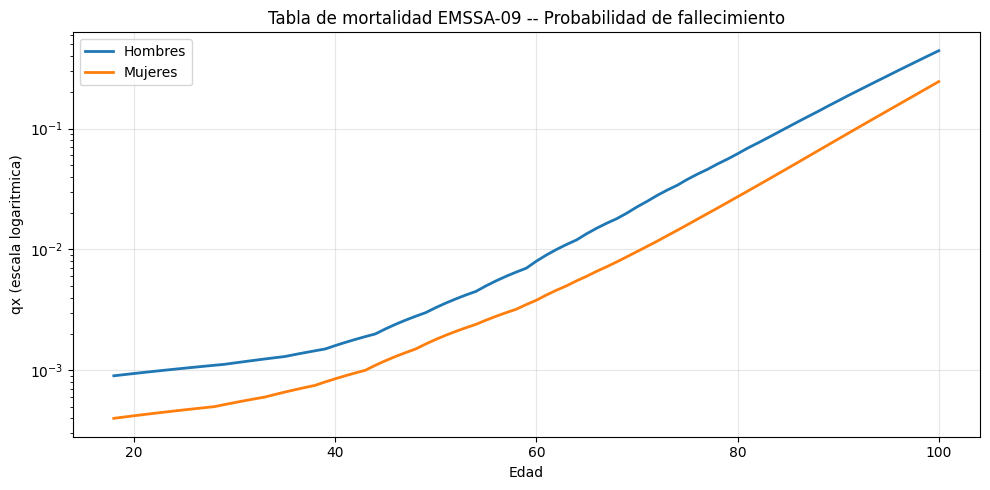

In [3]:
# Graficar curva qx para hombres y mujeres
df_h = tabla.obtener_tabla_completa(Sexo.HOMBRE).sort_values("edad")
df_m = tabla.obtener_tabla_completa(Sexo.MUJER).sort_values("edad")

fig, ax = plt.subplots()
ax.semilogy(df_h["edad"], df_h["qx"], label="Hombres", linewidth=2)
ax.semilogy(df_m["edad"], df_m["qx"], label="Mujeres", linewidth=2)
ax.set_xlabel("Edad")
ax.set_ylabel("qx (escala logaritmica)")
ax.set_title("Tabla de mortalidad EMSSA-09 -- Probabilidad de fallecimiento")
ax.legend()
plt.tight_layout()
plt.show()

## Paso 2: Funciones de conmutacion

Las funciones de conmutacion simplifican el calculo de primas y reservas.
Se construyen a partir de $l_x$ (sobrevivientes) y una **tasa de interes tecnico** $i = 5.5\%$.

| Funcion | Formula | Interpretacion |
|---------|---------|----------------|
| $D_x$   | $l_x \cdot v^x$ | Factor de descuento por sobrevivencia |
| $N_x$   | $\sum_{k=x}^{\omega} D_k$ | Acumulado de $D_x$ |
| $M_x$   | $\sum_{k=x}^{\omega} C_k$ | Acumulado del factor de mortalidad |

In [4]:
# Construir tabla de conmutacion a 5.5%
tc = TablaConmutacion(
    tabla_mortalidad=tabla,
    sexo=Sexo.HOMBRE,
    tasa_interes=Decimal("0.055"),
)
print(tc)
print()

# Mostrar valores para edades 25-65 (cada 5 anos)
print(f"{'Edad':>5}  {'Dx':>14}  {'Nx':>14}  {'Mx':>14}")
print("-" * 55)
for x in range(25, 66, 5):
    print(f"{x:5d}  {float(tc.Dx(x)):14,.2f}  {float(tc.Nx(x)):14,.2f}  {float(tc.Mx(x)):14,.4f}")

TablaConmutacion(tabla=EMSSA-09, sexo=H, i=0.055, edades=[18, 100])

 Edad              Dx              Nx              Mx
-------------------------------------------------------
   25       26,047.66      461,607.51      1,982.8092
   30       19,822.57      344,494.02      1,863.1627
   35       15,075.39      255,389.50      1,761.2440
   40       11,454.18      187,645.78      1,671.6993
   45        8,685.39      136,208.49      1,584.4774
   50        6,559.55       97,256.43      1,489.3083
   55        4,921.83       67,904.89      1,381.7598
   60        3,654.22       45,960.34      1,258.1880
   65        2,658.93       29,774.58      1,106.6996


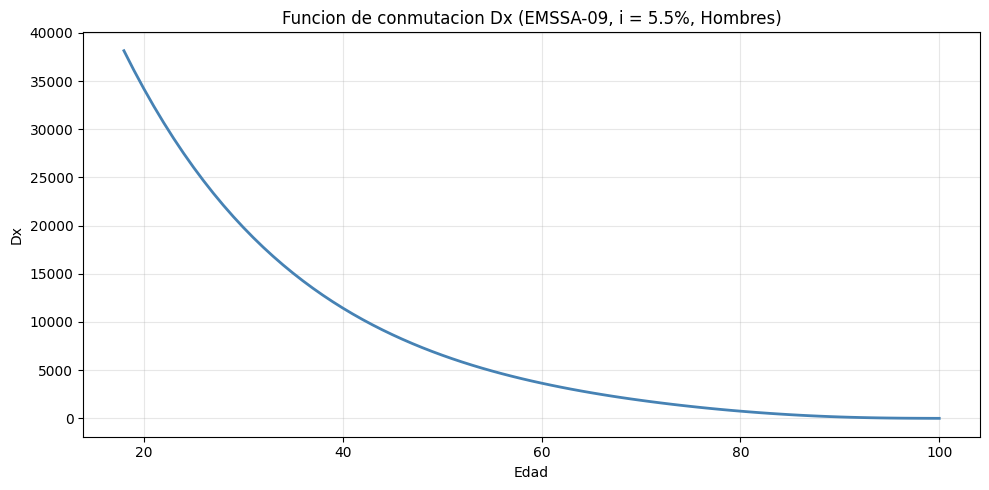

In [5]:
# Graficar Dx
edades_rango = list(range(tc.edad_min, tc.edad_max + 1))
dx_vals = [float(tc.Dx(x)) for x in edades_rango]

fig, ax = plt.subplots()
ax.plot(edades_rango, dx_vals, linewidth=2, color="steelblue")
ax.set_xlabel("Edad")
ax.set_ylabel("Dx")
ax.set_title("Funcion de conmutacion Dx (EMSSA-09, i = 5.5%, Hombres)")
plt.tight_layout()
plt.show()

## Paso 3: Configurar producto y asegurado

Se configura un **Seguro de Vida Temporal a 20 anos** con los siguientes parametros:

- Tasa de interes tecnico: 5.5%
- Recargos: 5% administracion, 10% adquisicion, 3% utilidad
- Asegurado: hombre de 35 anos, suma asegurada $1,000,000 MXN

In [6]:
# Configuracion del producto
config = ConfiguracionProducto(
    nombre_producto="Vida Temporal 20 anos",
    plazo_years=20,
    tasa_interes_tecnico=Decimal("0.055"),
    recargo_gastos_admin=Decimal("0.05"),
    recargo_gastos_adq=Decimal("0.10"),
    recargo_utilidad=Decimal("0.03"),
)

# Crear producto
producto_temporal = VidaTemporal(config, tabla)
print(producto_temporal)

# Asegurado
asegurado = Asegurado(
    edad=35,
    sexo=Sexo.HOMBRE,
    suma_asegurada=Decimal("1000000"),
)
print(f"\nAsegurado: {asegurado.sexo.value}, {asegurado.edad} anos, SA = ${asegurado.suma_asegurada:,.0f} MXN")

VidaTemporal(plazo=20 años, tabla=EMSSA-09)

Asegurado: H, 35 anos, SA = $1,000,000 MXN


## Paso 4: Calcular prima

Se calcula la prima nivelada anual. El metodo `calcular_prima` devuelve un `ResultadoCalculo`
con la prima neta, la prima total (con recargos) y el desglose de cada recargo.

In [7]:
resultado = producto_temporal.calcular_prima(asegurado)

print("=" * 50)
print("RESULTADO DE TARIFICACION")
print("=" * 50)
print(f"Prima neta anual:  ${resultado.prima_neta:>12,.2f} MXN")
print(f"Prima total anual: ${resultado.prima_total:>12,.2f} MXN")
print()
print("Desglose de recargos:")
for nombre, monto in resultado.desglose_recargos.items():
    print(f"  {nombre:20s}: ${monto:>10,.2f}")
print()
print("Metadata:")
for k, v in resultado.metadata.items():
    print(f"  {k}: {v}")

RESULTADO DE TARIFICACION
Prima neta anual:  $    2,024.08 MXN
Prima total anual: $    2,388.42 MXN

Desglose de recargos:
  gastos_admin        : $    101.20
  gastos_adq          : $    202.41
  utilidad            : $     60.72

Metadata:
  producto: Vida Temporal 20 anos
  plazo_seguro: 20
  plazo_pago: 20
  frecuencia_pago: anual
  tabla_mortalidad: EMSSA-09
  tasa_interes: 0.055
  edad: 35
  sexo: H


## Paso 5: Reserva matematica por ano de poliza

La **reserva matematica** $V_t$ en el ano $t$ mide la obligacion acumulada del asegurador.
Para un temporal, la reserva sube durante la vigencia y regresa a cero al vencimiento
(porque si el asegurado sobrevive, no hay pago).

 Ano   Reserva
   0     $0.00
   1   $836.49
   2 $1,670.16
   3 $2,500.93
   4 $3,328.71
   5 $4,153.43
   6 $4,925.15
   7 $5,641.03
   8 $6,298.03
   9 $6,892.93
  10 $7,422.29
  11 $7,783.04
  12 $7,965.63
  13 $7,959.85
  14 $7,754.76
  15 $7,338.69
  16 $6,599.50
  17 $5,517.75
  18 $4,072.51
  19 $2,241.32
  20     $0.00


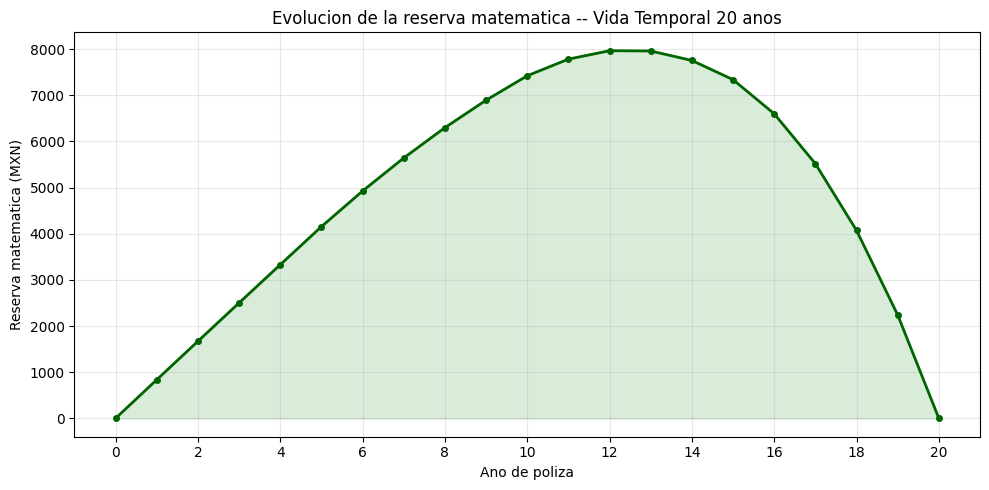

In [8]:
# Calcular reservas para cada ano
anios = list(range(0, 21))
reservas = []
for t in anios:
    r = producto_temporal.calcular_reserva(asegurado, anio=t)
    reservas.append(float(r))

# Tabla resumen
df_reservas = pd.DataFrame({"Ano": anios, "Reserva": reservas})
print(df_reservas.to_string(index=False, float_format="${:,.2f}".format))

# Graficar
fig, ax = plt.subplots()
ax.plot(anios, reservas, marker="o", markersize=4, linewidth=2, color="darkgreen")
ax.fill_between(anios, reservas, alpha=0.15, color="green")
ax.set_xlabel("Ano de poliza")
ax.set_ylabel("Reserva matematica (MXN)")
ax.set_title("Evolucion de la reserva matematica -- Vida Temporal 20 anos")
ax.set_xticks(range(0, 21, 2))
plt.tight_layout()
plt.show()

## Paso 6: Analisis de sensibilidad -- edad vs. prima

Se calcula la prima anual neta para edades de 25 a 65 anos, manteniendo constantes
el plazo (20 anos), la tasa de interes y la suma asegurada. Se espera un crecimiento
exponencial de la prima conforme aumenta la edad de emision.

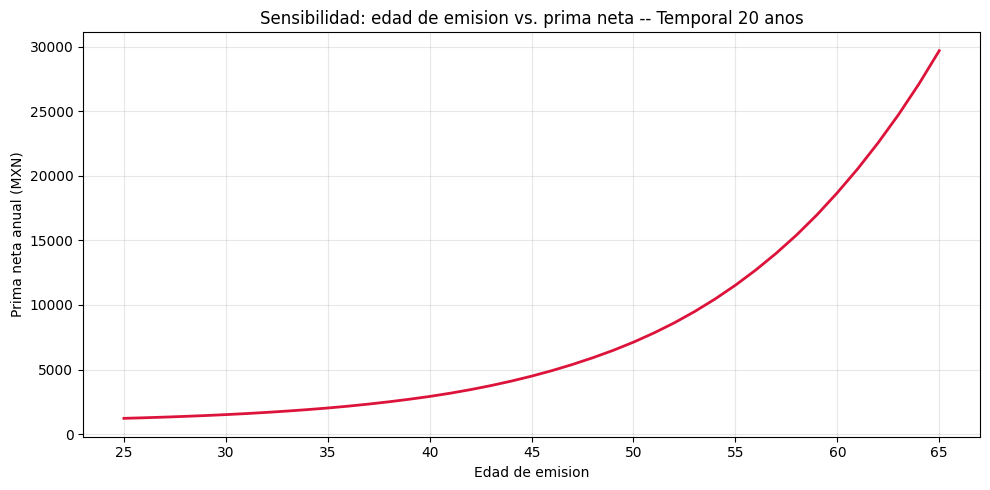

In [9]:
edades = list(range(25, 66))
primas_netas = []

for e in edades:
    aseg_i = Asegurado(edad=e, sexo=Sexo.HOMBRE, suma_asegurada=Decimal("1000000"))
    try:
        res_i = producto_temporal.calcular_prima(aseg_i)
        primas_netas.append(float(res_i.prima_neta))
    except ValueError:
        primas_netas.append(None)

fig, ax = plt.subplots()
ax.plot(edades, primas_netas, linewidth=2, color="crimson")
ax.set_xlabel("Edad de emision")
ax.set_ylabel("Prima neta anual (MXN)")
ax.set_title("Sensibilidad: edad de emision vs. prima neta -- Temporal 20 anos")
plt.tight_layout()
plt.show()

## Paso 7: Comparacion de los 3 productos de vida

Para el mismo asegurado (hombre, 35 anos, SA = $1,000,000), se comparan:

| Producto | Caracteristica |
|----------|----------------|
| **Temporal** | Paga solo si fallece durante el plazo |
| **Ordinario** | Paga al fallecimiento (cobertura vitalicia, pago limitado a 20 anos) |
| **Dotal** | Paga al fallecimiento O al sobrevivir el plazo |

           Producto  Prima Neta  Prima Total
        Temporal 20   $2,024.08    $2,388.42
Ordinario (pago 20)   $9,376.84   $11,064.67
           Dotal 20  $28,275.97   $33,365.64


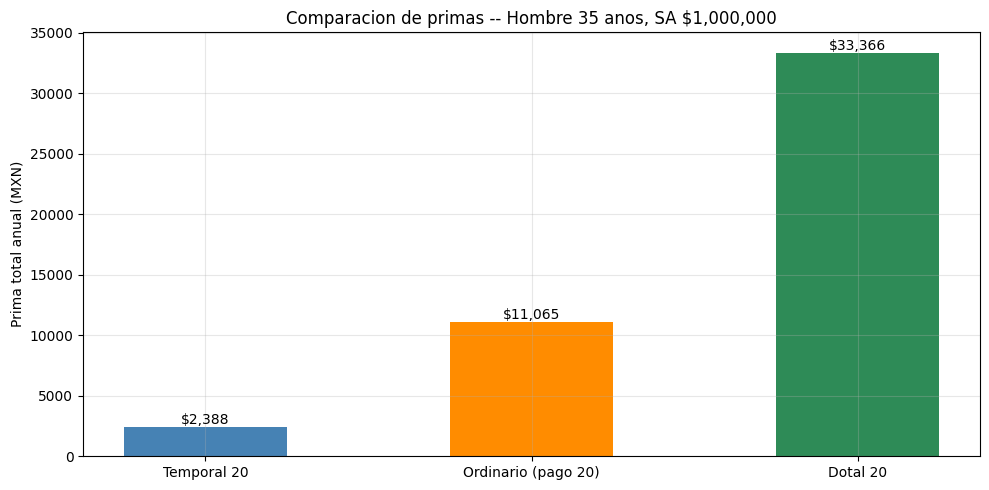

In [10]:
# Asegurado comun
aseg = Asegurado(edad=35, sexo=Sexo.HOMBRE, suma_asegurada=Decimal("1000000"))

# Configuracion comun
cfg = ConfiguracionProducto(
    nombre_producto="Comparativo",
    plazo_years=20,
    tasa_interes_tecnico=Decimal("0.055"),
    recargo_gastos_admin=Decimal("0.05"),
    recargo_gastos_adq=Decimal("0.10"),
    recargo_utilidad=Decimal("0.03"),
)

# Productos
p_temporal = VidaTemporal(cfg, tabla)
p_ordinario = VidaOrdinario(cfg, tabla)  # plazo_years=20 -> pago limitado 20 anos
p_dotal = VidaDotal(cfg, tabla)

r_temporal = p_temporal.calcular_prima(aseg)
r_ordinario = p_ordinario.calcular_prima(aseg)
r_dotal = p_dotal.calcular_prima(aseg)

# Tabla comparativa
df_comp = pd.DataFrame({
    "Producto": ["Temporal 20", "Ordinario (pago 20)", "Dotal 20"],
    "Prima Neta": [float(r_temporal.prima_neta), float(r_ordinario.prima_neta), float(r_dotal.prima_neta)],
    "Prima Total": [float(r_temporal.prima_total), float(r_ordinario.prima_total), float(r_dotal.prima_total)],
})
print(df_comp.to_string(index=False, float_format="${:,.2f}".format))

# Grafica de barras
fig, ax = plt.subplots()
x_pos = range(len(df_comp))
bars = ax.bar(x_pos, df_comp["Prima Total"], color=["steelblue", "darkorange", "seagreen"], width=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_comp["Producto"])
ax.set_ylabel("Prima total anual (MXN)")
ax.set_title("Comparacion de primas -- Hombre 35 anos, SA $1,000,000")
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f"${height:,.0f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

## Conclusiones

1. **Temporal < Ordinario < Dotal** en costo de prima: el temporal es puro riesgo
   (no paga si sobrevive), mientras que el dotal garantiza el pago en ambos escenarios,
   incorporando un componente de ahorro que encarece la prima.

2. La **reserva matematica** del temporal sube y baja durante la vigencia, regresando
   a cero al vencimiento. En contraste, la reserva del dotal crece monotonamente hasta
   alcanzar la suma asegurada.

3. La **prima crece exponencialmente** con la edad de emision, reflejando la curva de
   mortalidad $q_x$ de la tabla EMSSA-09.

4. Las **funciones de conmutacion** permiten verificar rapidamente los calculos intermedios
   y son la base de la matematica actuarial clasica utilizada por la CNSF.